## COVID Drivers: Modeling

This notebook models

 POST_COVID ~ each outcome variable separately (aggressive and distracted driving)

 These models fulfill the following secondary objective: Identify specific aggressive [or distracted] driving behaviors that increased during COVID-19.

Source: https://machinelearningmastery.com/one-class-classification-algorithms/

### Table of Contents
* [Read the Data](#read)</BR>
* [Create Structures for Visualizations](#viz)</BR>
* [Local Outlier Factor](#lof)
* [Review Models](#review)


Import packages

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import xgboost as xgb
from functools import reduce
#import prince

from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path_in = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/ready/ready_data_final.csv'

### <a id='read'>Read the data</a>

In [ ]:
df_init = pd.read_csv(path_in, low_memory=False)

In [ ]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [ ]:
df_ = df_init.set_index('CRASH_DATE').\
  drop(columns=['CRN']).\
  copy()

In [ ]:
df15_ = df_init.loc[df_init['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')].\
  set_index('CRASH_DATE').\
  drop(columns=['CRN']).\
  copy()

### <a id='viz'>Create Structures for Visualizations</a>

In [ ]:
summ15_ = df15_.groupby(['CRASH_DATE']).\
    aggregate(POST_COVID=('POST_COVID', 'median'),
              AGGRESSIVE_DRIVING_rate=('AGGRESSIVE_DRIVING','mean'),
              NHTSA_AGG_DRIVING_rate=('NHTSA_AGG_DRIVING','mean'),
              NO_CLEARANCE_rate=('NHTSA_AGG_DRIVING','mean'),
              RUNNING_RED_LT_rate=('RUNNING_RED_LT','mean'),
              RUNNING_STOP_SIGN_rate=('RUNNING_STOP_SIGN','mean'),
              SPEEDING_rate=('SPEEDING','mean'),
              SPEEDING_RELATED_rate=('SPEEDING_RELATED','mean'),
              TAILGATING_rate=('TAILGATING','mean'),
              CELL_PHONE_rate=('CELL_PHONE','mean'),
              DISTRACTED_rate=('DISTRACTED','mean')).\
    reset_index().\
    copy()

In [ ]:
summ15_['POST_COVIDx'] = ['Before COVID' if x==0 else 'After COVID' for x in summ15_['POST_COVID']]

In [ ]:
summ15_.head()

,CRASH_DATE,POST_COVID,AGGRESSIVE_DRIVING_rate,NHTSA_AGG_DRIVING_rate,NO_CLEARANCE_rate,RUNNING_RED_LT_rate,RUNNING_STOP_SIGN_rate,SPEEDING_rate,SPEEDING_RELATED_rate,TAILGATING_rate,CELL_PHONE_rate,DISTRACTED_rate,POST_COVIDx
0,2015-03-01,0.0,0.590070,0.046961,0.046961,0.029420,0.020232,0.026357,0.348492,0.036009,0.007332,0.092343,Before COVID
1,2015-04-01,0.0,0.531305,0.056080,0.056080,0.039874,0.022152,0.036610,0.203334,0.049784,0.009560,0.137461,Before COVID
2,2015-05-01,0.0,0.524137,0.050562,0.050562,0.035533,0.026575,0.036827,0.189211,0.049069,0.010351,0.137255,Before COVID
3,2015-06-01,0.0,0.547467,0.058077,0.058077,0.038075,0.025180,0.032592,0.229465,0.050157,0.009240,0.127729,Before COVID
4,2015-07-01,0.0,0.525806,0.056145,0.056145,0.041001,0.027403,0.036778,0.192438,0.054394,0.009684,0.136912,Before COVID


In [ ]:
summ_ = df_.groupby(['CRASH_DATE']).\
    aggregate(POST_COVID=('POST_COVID', 'median'),
              AGGRESSIVE_DRIVING_rate=('AGGRESSIVE_DRIVING','mean'),
              NHTSA_AGG_DRIVING_rate=('NHTSA_AGG_DRIVING','mean'),
              NO_CLEARANCE_rate=('NHTSA_AGG_DRIVING','mean'),
              RUNNING_RED_LT_rate=('RUNNING_RED_LT','mean'),
              RUNNING_STOP_SIGN_rate=('RUNNING_STOP_SIGN','mean'),
              SPEEDING_rate=('SPEEDING','mean'),
              SPEEDING_RELATED_rate=('SPEEDING_RELATED','mean'),
              TAILGATING_rate=('TAILGATING','mean'),
              CELL_PHONE_rate=('CELL_PHONE','mean'),
              DISTRACTED_rate=('DISTRACTED','mean')).\
    reset_index().\
    copy()

In [ ]:
summ_['POST_COVIDx'] = ['Before COVID' if x==0 else 'After COVID' for x in summ_['POST_COVID']]

In [ ]:
def plot_time_series(summ, c):
    cr = c+'_rate'
    ax = sns.lineplot(summ, x='CRASH_DATE', y=cr, hue='POST_COVIDx')
    plt.title(c.replace('_',' ').title() + ' Rate Over Time')
    plt.xlabel(c.replace('_',' ').title())
    plt.ylabel('Rate')
    ax.legend_.set_title("COVID")
    print(plt.show())

### <a id='lof'>Local Outlier Factor</a>

In [ ]:
def lof_predict(model, X_train, X_test):
	# create one large dataset
	composite = np.vstack((X_train, X_test))
	# make prediction on composite dataset
	yhat = model.fit_predict(composite)
	# return just the predictions on the test set
	return yhat[len(X_train):]

In [ ]:
def one_class_lof(df, X, c, summ):
    print(c)
    print()

    contamination = df.loc[df[c]==1].shape[0]/df.shape[0]
    model = LocalOutlierFactor(contamination=contamination)

    y = df[c]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

    # fit on majority class
    X_train = X_train[y_train==0]
    model.fit(X_train)

    # detect outliers in the test set
    yhat = lof_predict(model, X_train, X_test)

    # mark inliers 1, outliers -1
    y_test[y_test == 1] = -1
    y_test[y_test == 0] = 1

    # calculate score
    score = f1_score(y_test, yhat, pos_label=-1)
    print('F1 Score: %.3f' % score)

    """# Compute permutation importance
    results = permutation_importance(model, X_test, y_test, n_repeats=3, random_state=42, scoring='f1')

    for i, importance in enumerate(results.importances_mean):
        print(f"Feature {i+1}: {importance}")
"""
    plot_time_series(summ, c)

    print()
    print()

In [ ]:
X15_ = df15_.loc[:,['POST_COVID']].to_numpy().copy()

In [ ]:
X_ = df_.loc[:,['POST_COVID']].to_numpy().copy()

#### Run with records from March 1, 2025 and later

In [ ]:
#one_class_lof(df15_, X15_, 'AGGRESSIVE_DRIVING', summ15_)

In [ ]:
#one_class_lof(df15_, X15_, 'NHTSA_AGG_DRIVING', summ15_)

NO_CLEARANCE

F1 Score: 0.000


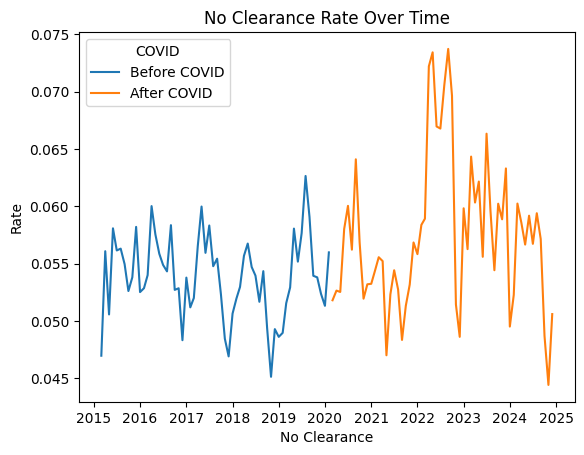

None




In [ ]:
one_class_lof(df15_, X15_, 'NO_CLEARANCE', summ15_)

RUNNING_RED_LT

F1 Score: 0.000


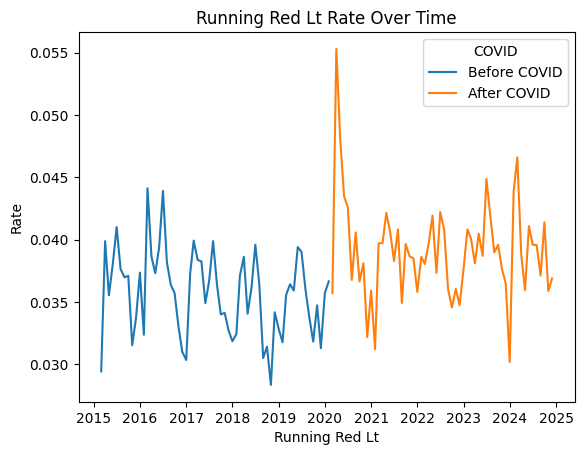

None




In [ ]:
one_class_lof(df15_, X15_, 'RUNNING_RED_LT', summ15_)

In [ ]:
one_class_lof(df15_, X15_, 'RUNNING_STOP_SIGN', summ15_)

RUNNING_STOP_SIGN



In [ ]:
one_class_lof(df15_, X15_, 'SPEEDING', summ15_)

SPEEDING



In [ ]:
one_class_lof(df15_, X15_, 'SPEEDING_RELATED', summ15_)

SPEEDING_RELATED



In [ ]:
one_class_lof(df15_, X15_, 'TAILGATING', summ15_)

TAILGATING



In [ ]:
one_class_lof(df15_, X15_, 'CELL_PHONE', summ15_)

In [ ]:
one_class_lof(df15_, X15_, 'DISTRACTED', summ15_)

#### Run with all records

In [ ]:
#one_class_lof(df_, X_, 'AGGRESSIVE_DRIVING', summ_)

In [ ]:
#one_class_lof(df_, X_, 'NHTSA_AGG_DRIVING', summ_)

In [ ]:
one_class_lof(df_, X_, 'NO_CLEARANCE', summ_)

In [ ]:
one_class_lof(df_, X_, 'RUNNING_RED_LT', summ_)

In [ ]:
one_class_lof(df_, X_, 'RUNNING_STOP_SIGN', summ_)

In [ ]:
one_class_lof(df_, X_, 'SPEEDING', summ_)

In [ ]:
one_class_lof(df_, X_, 'SPEEDING_RELATED', summ_)

In [ ]:
one_class_lof(df_, X_, 'TAILGATING', summ_)

In [ ]:
one_class_lof(df_, X_, 'CELL_PHONE', summ_)

In [ ]:
one_class_lof(df_, X_, 'DISTRACTED', summ_)